## TÓPICOS ESPECIAIS EM SISTEMAS COMPUTACIONAIS II

#### Alunos:
João Felype Feitosa Rêgo 20250202545  
Andrey de Oliveira Sabino 2025022571

In [0]:
import pandas as pd

# Leitura dos dados
colunas = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "num"
]

caminho = "/Volumes/workspace/topicos_ll/dados_atividade_2/processed.cleveland.data"

df = pd.read_csv(caminho, names=colunas, na_values="?")

display(df)

age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [0]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Questão 1.
# A)
# Substituindo valores nulos pelo valor da mediana em todo o dataframe.
df = df.fillna(df.median(numeric_only=True))

# B)
# Transformando a coluna num em binário. Se x > 0, então x = 1, caso contrário x = 0.
df["num"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

display(df)

# C) 
# separar features (X) e target (y).
X = df.drop("num", axis=1)
y = df["num"]

# Divisão do treino e teste (80% treino e 20% teste) com stratify.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# D)
# Seleção das colunas contínuas.
colunas_continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Criando o scaler.
scaler = StandardScaler()

# Ajustar no treino e transformar.
X_train[colunas_continuas] = scaler.fit_transform(X_train[colunas_continuas])

# Aplicar no teste (sem ajustar novamente!).
X_test[colunas_continuas] = scaler.transform(X_test[colunas_continuas])

# Resultados.
print(X_train[colunas_continuas].head())


age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


          age  trestbps      chol   thalach   oldpeak
180 -0.729485 -0.395692  0.458139  0.708371 -0.445445
208  0.050166 -0.054513  0.230598  0.222495 -0.891627
167 -0.061212  0.059213  0.723605  0.399178 -0.891627
105 -0.061212 -1.305501  1.121803  0.266666 -0.891627
297  0.272924  0.514117 -0.167601 -1.190962 -0.713154


In [0]:
from sklearn.linear_model import LogisticRegression

# Questão 2.
# Treinando o modelo.
modelo = LogisticRegression(
    solver='liblinear',
    random_state=42,
    max_iter=1000
)

modelo.fit(X_train, y_train)

# Resultado.
print("Foram necessarias", modelo.n_iter_[0], "iterações para a convergência.")

Foram necessarias 5 iterações para a convergência.


Acurácia: 0.8689
Precisão: 0.8125
Recall: 0.9286
F1-score: 0.8667
AUC: 0.9545


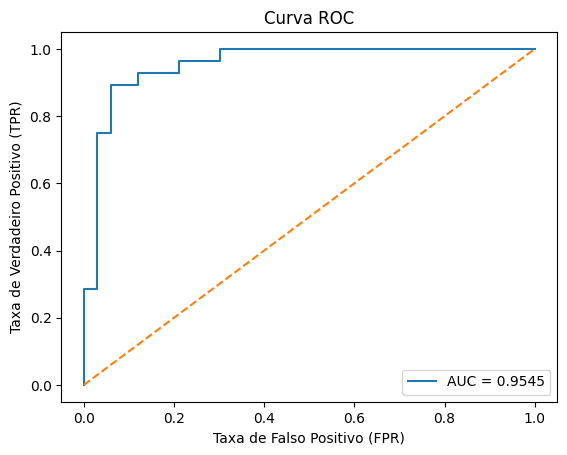

In [0]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Questão 4.
# Predições.
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# A) Calculo da Acurácia e resultado.
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia: {acuracia:.4f}")

# B) Calculo da Precisão e resultado.
precisao = precision_score(y_test, y_pred)
print(f"Precisão: {precisao:.4f}")

# C) Calculo da Recall e resultado.
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# D) Calculo da F1-score e resultado.
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.4f}")

# E) Calculo da ROC + AUC e resultado.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}")

# Plotagem da Curva ROC.
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taxa de Falso Positivo (FPR)")
plt.ylabel("Taxa de Verdadeiro Positivo (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.show()